In [1]:
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
# =========================================
# 1. Generate Training Data
# =========================================
# Generate random integer: np.random.randint(low, high, size)
# generate data
def generate_data(low, high, n_rows, n_cols):
    x_data = np.random.randint(low, high, (n_rows, n_cols))
    y_data = np.sum(x_data, axis=1)
    return x_data, y_data
# new training and testing datasets
x_train, y_train = generate_data(-100, 100, 500, 3)
x_test, y_test = generate_data(-100, 100, 20, 3)

In [3]:
# =========================================
# 2. Build Neural Network
# three inputs -> first hidden layer with 16 neurons, activation function is relu -> 
# second hidden layer with 8 neurons, activation function is relu-> output layer with one output
# =========================================

model = keras.Sequential([
    keras.Input(shape=(3,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1)
])

In [4]:
# =========================================
# 3. Compile Model
# configure optimizer, loss function
# optimizer is adam, adam adapts learning individually for each parameter
# loss function is mse as it is a regression problem
# =========================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[keras.metrics.RootMeanSquaredError()]
)

In [5]:
# =========================================
# 4. Train Model
# train NN using training data, epochs=100: training the entire dataset 100 times, verbose=1: progress bar shown
# =========================================

history = model.fit(
    x_train,
    y_train,
    epochs=100,
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 10501.5713 - root_mean_squared_error: 102.4772
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9372.5391 - root_mean_squared_error: 96.8119  
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8246.4365 - root_mean_squared_error: 90.8099   
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7121.7749 - root_mean_squared_error: 84.3906 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6088.2524 - root_mean_squared_error: 78.0273 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5092.0210 - root_mean_squared_error: 71.3584
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4116.9551 - root_mean_squared_error: 64.1635 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3249.1196 - root_mean_squared_error: 57.0010 
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2420.3198 - root_mean_squared_error: 49.1967 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 12.4664 - root_mean_squared_error: 3.5308
Test Loss: 12.46644115447998
Test RMSE: 3.530784845352173
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
    x1  x2  x3    y   predicted  rounded_predicted
0   51 -33  28   46   45.330170               45.0
1   10   0  86   96   91.462585               91.0
2    2   0 -40  -38  -39.642616              -40.0
3  -79 -85  55 -109 -105.731873             -106.0
4   62  87  86  235  231.864151              232.0
5   33  21 -60   -6  -10.716765              -11.0
6   41  11 -63  -11  -14.841812              -15.0
7  -63  42  41   20   26.109304               26.0
8   44 -71 -30  -57  -60.041859              -60.0
9   82  96  92  270  266.705048              267.0
10 -92  18 -91 -165 -160.721542             -161.0
11  77  94  64  235  233.001831              233.0
12  47  25  95  167  168.448242              168.0
13  94 -26 -11   57   56.724140               57.0
14  98 -65  30   63   63.874405               64.0

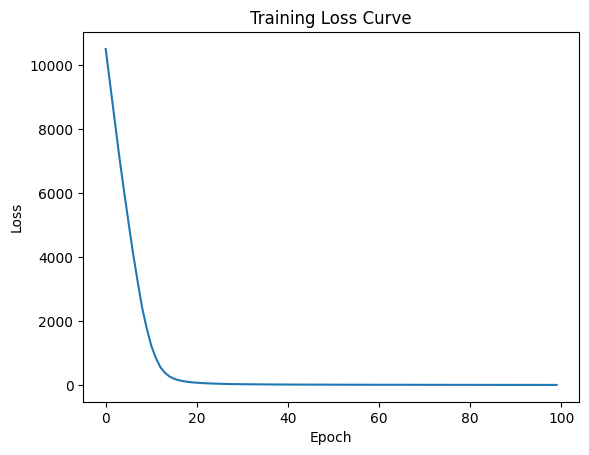

In [9]:
# evaluate model on test data
test_loss, test_rmse = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test RMSE:", test_rmse)

# make predictions
predictions = model.predict(x_test)

# flatten prediction array
predictions = predictions.flatten()

# create tabular dataframe
results_df = pd.DataFrame({
    'x1': x_test[:, 0],
    'x2': x_test[:, 1],
    'x3': x_test[:, 2],
    'y': y_test,
    'predicted': predictions,
    'rounded_predicted': np.round(predictions)
})

# display table
print(results_df)

# plot loss curve
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()


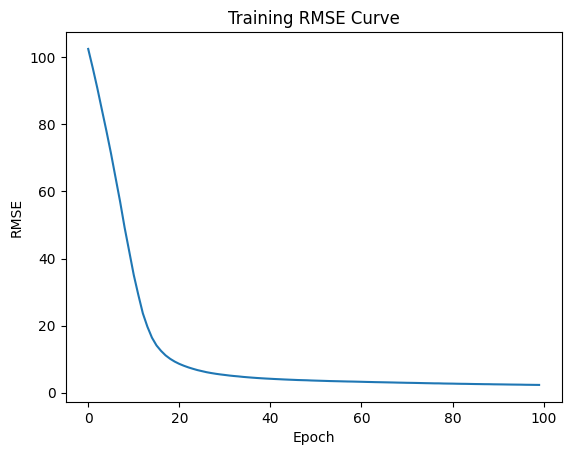

In [10]:
# plot RMSE curve
plt.plot(history.history['root_mean_squared_error'])
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training RMSE Curve')
plt.show()